## IDS Modeling

Network Duplicate, we need no trainings here

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from phis_init import phi_init

from Channel_Current_Ich import (
    channel_integral_I_phi,
    channel_current_Ich
)

class DeltaPhisPINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.Tanh(),
            nn.Linear(8, 1)
        )

    def forward(self, Vgs, Vds):

        Vgs = Vgs.reshape(-1, 1)
        Vds = Vds.reshape(-1, 1)

        x = torch.cat(
            [Vgs, Vds],
            dim=1
        )

        return self.net(x)


device = (
    "xpu"
    if torch.xpu.is_available()
    else "cpu"
)

dtype = torch.float32

print("device =", device)
print("dtype  =", dtype)

device = xpu
dtype  = torch.float32


## Parameters transfer
Need to be correspondent

In [2]:
# ============================================================
# Physical parameters
# ============================================================

T = 300.0                         # K

NA = 1e16                        # cm^-3

# Absolute permittivity of 4H-SiC
eps_sic = 9.26 * 8.854e-14       # F/cm

Cox = 7e-8                       # F/cm^2

Vfbs0 = -1.0                     # V

Dit_mid = 2e11                   # cm^-2 eV^-1

Dit_edge = 2e13                  # cm^-2 eV^-1

sigma_it = 0.1                   # eV

Eg = 3.26                        # eV

Ec_minus_Ei = Eg / 2.0           # eV

Qox = 1.602e-7                   # C/cm^2


# ============================================================
# Valid voltage range of trained PINN
# ============================================================

VGS_MIN = -10.0
VGS_MAX = 30.0

VDS_MIN = 0.0
VDS_MAX = 15.0

In [3]:
Model = DeltaPhisPINN().to(
    device=device,
    dtype=dtype
)

Model.load_state_dict(
    torch.load(
        "phis_PINN.pth",
        map_location=device
    )
)

Model.eval()

print("Surface-potential PINN loaded.")



Surface-potential PINN loaded.


Redefine Outputs

In [4]:
def predict_phis(
    Model,
    Vgs,
    Vds
):

    # --------------------------------------------------------
    # Ensure tensor shape
    # --------------------------------------------------------

    Vgs = Vgs.reshape(-1, 1)
    Vds = Vds.reshape(-1, 1)


    # --------------------------------------------------------
    # Drain-side quasi-Fermi potential
    # --------------------------------------------------------

    phi_f = Vds


    # --------------------------------------------------------
    # Analytical initial surface potential
    # --------------------------------------------------------

    phis_init = phi_init(
        Vgs,
        phi_f,
        T,
        NA,
        eps_sic,
        Cox,
        Vfbs0,
        Dit_mid,
        Dit_edge,
        sigma_it,
        Eg,
    ).reshape(-1, 1)


    # --------------------------------------------------------
    # PINN correction
    # --------------------------------------------------------

    delta_phis = Model(
        Vgs,
        Vds
    )


    # --------------------------------------------------------
    # Final surface potential
    # --------------------------------------------------------

    phis = (
        phis_init
        + delta_phis
    )


    return phis

In [5]:
def predict_phis_source(
    Model,
    Vgs
):

    Vds_source = torch.zeros_like(
        Vgs
    )

    phis_s0 = predict_phis(
        Model,
        Vgs,
        Vds_source
    )

    return phis_s0

def predict_phis_drain(
    Model,
    Vgs,
    Vds
):

    phis_sL = predict_phis(
        Model,
        Vgs,
        Vds
    )

    return phis_sL

In [6]:
VGS_TEST = 15.0
VDS_TEST = 5.0

Vgs_test = torch.tensor(
    [[VGS_TEST]],
    dtype=dtype,
    device=device
)

Vds_test = torch.tensor(
    [[VDS_TEST]],
    dtype=dtype,
    device=device
)


with torch.no_grad():

    phis_s0_test = predict_phis_source(
        Model,
        Vgs_test
    )

    phis_sL_test = predict_phis_drain(
        Model,
        Vgs_test,
        Vds_test
    )


print(
    "Vgs      =",
    Vgs_test.item(),
    "V"
)

print(
    "Vds      =",
    Vds_test.item(),
    "V"
)

print(
    "phis_s0  =",
    phis_s0_test.item(),
    "V"
)

print(
    "phis_sL  =",
    phis_sL_test.item(),
    "V"
)

Vgs      = 15.0 V
Vds      = 5.0 V
phis_s0  = 3.0900118350982666 V
phis_sL  = 8.059208869934082 V


## Params Definition


In [ ]:
# First-stage IV parameters(Waiting to be detailed)

W_eff_cm = 1.0

Lch_cm = 1.0e-4

mu_eff_cm2_Vs = 20.0

lambda_clm = 0.0

Workpoint calc

In [8]:
with torch.no_grad():

    Ich_test = channel_current_Ich(
        Vgs_test,
        Vds_test,

        phis_s0_test,
        phis_sL_test,

        Vfbs0,
        Cox,
        Qox,

        Dit_mid,
        Dit_edge,
        sigma_it,

        Ec_minus_Ei,

        T,
        NA,
        Eg,
        eps_sic,

        W_eff_cm,
        Lch_cm,
        mu_eff_cm2_Vs,
        lambda_clm,
    )


print(
    "Ich =",
    Ich_test.item(),
    "A"
)

Ich = 0.41214197874069214 A


In [9]:
with torch.no_grad():

    I_phi_test = channel_integral_I_phi(
        Vgs_test,
        Vds_test,

        phis_s0_test,
        phis_sL_test,

        Vfbs0,
        Cox,
        Qox,

        Dit_mid,
        Dit_edge,
        sigma_it,

        Ec_minus_Ei,

        T,
        NA,
        Eg,
        eps_sic,
    )


print(
    "I_phi =",
    I_phi_test.item()
)

print(
    "Ich   =",
    Ich_test.item(),
    "A"
)

I_phi = 2.0607099031622056e-06
Ich   = 0.41214197874069214 A


Curve fitting

In [10]:
N_plot = 400

Vgs_plot = torch.linspace(
    VGS_MIN,
    VGS_MAX,
    N_plot,
    dtype=dtype,
    device=device
).reshape(-1, 1)


VDS_VALUE = 5.0

Vds_plot = torch.full_like(
    Vgs_plot,
    VDS_VALUE
)

In [11]:
with torch.no_grad():

    # --------------------------------------------------------
    # Source-side surface potential
    # --------------------------------------------------------

    phis_s0 = predict_phis_source(
        Model,
        Vgs_plot
    )


    # --------------------------------------------------------
    # Drain-side surface potential
    # --------------------------------------------------------

    phis_sL = predict_phis_drain(
        Model,
        Vgs_plot,
        Vds_plot
    )


    # --------------------------------------------------------
    # Channel current
    # --------------------------------------------------------

    Ich_plot = channel_current_Ich(
        Vgs_plot,
        Vds_plot,

        phis_s0,
        phis_sL,

        Vfbs0,
        Cox,
        Qox,

        Dit_mid,
        Dit_edge,
        sigma_it,

        Ec_minus_Ei,

        T,
        NA,
        Eg,
        eps_sic,

        W_eff_cm,
        Lch_cm,
        mu_eff_cm2_Vs,
        lambda_clm,
    )

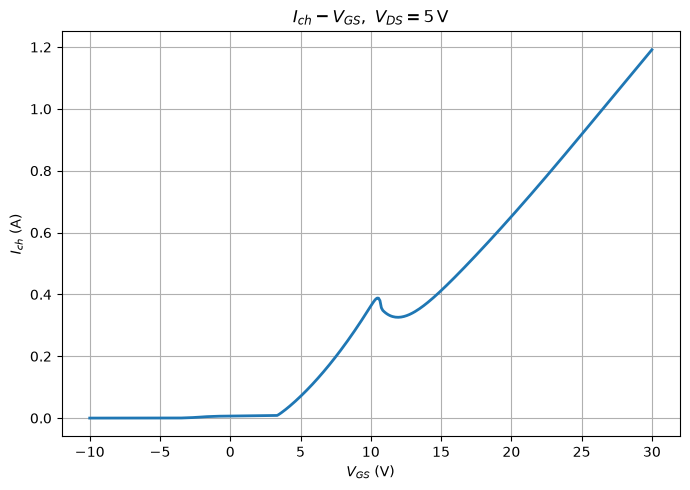

In [12]:
plt.figure(
    figsize=(7, 5)
)

plt.plot(
    Vgs_plot.cpu().numpy(),
    Ich_plot.cpu().numpy(),
    linewidth=2
)

plt.xlabel(
    r"$V_{GS}$ (V)"
)

plt.ylabel(
    r"$I_{ch}$ (A)"
)

plt.title(
    rf"$I_{{ch}}-V_{{GS}},\ V_{{DS}}={VDS_VALUE:.0f}\,\mathrm{{V}}$"
)

plt.grid(True)

plt.tight_layout()

plt.show()

Multiple IV curves

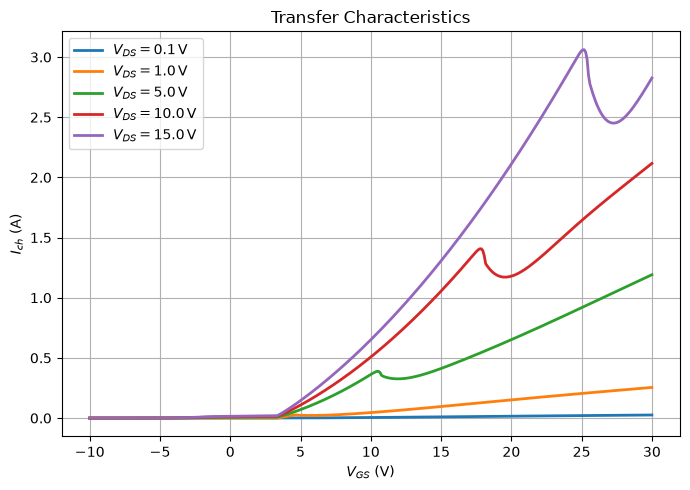

In [13]:
VDS_PLOT = [
    0.1,
    1.0,
    5.0,
    10.0,
    15.0,
]


plt.figure(
    figsize=(7, 5)
)


with torch.no_grad():

    for VDS_VALUE in VDS_PLOT:

        Vds_plot = torch.full_like(
            Vgs_plot,
            VDS_VALUE
        )


        phis_s0 = predict_phis_source(
            Model,
            Vgs_plot
        )


        phis_sL = predict_phis_drain(
            Model,
            Vgs_plot,
            Vds_plot
        )


        Ich_plot = channel_current_Ich(
            Vgs_plot,
            Vds_plot,

            phis_s0,
            phis_sL,

            Vfbs0,
            Cox,
            Qox,

            Dit_mid,
            Dit_edge,
            sigma_it,

            Ec_minus_Ei,

            T,
            NA,
            Eg,
            eps_sic,

            W_eff_cm,
            Lch_cm,
            mu_eff_cm2_Vs,
            lambda_clm,
        )


        plt.plot(
            Vgs_plot.cpu().numpy(),
            Ich_plot.cpu().numpy(),
            linewidth=2,
            label=rf"$V_{{DS}}={VDS_VALUE}\,\mathrm{{V}}$"
        )


plt.xlabel(
    r"$V_{GS}$ (V)"
)

plt.ylabel(
    r"$I_{ch}$ (A)"
)

plt.title(
    r"Transfer Characteristics"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

Expect: Vds = 0V

In [14]:
Vgs_zero_test = torch.tensor(
    [[15.0]],
    dtype=dtype,
    device=device
)

Vds_zero_test = torch.zeros_like(
    Vgs_zero_test
)


with torch.no_grad():

    phis_s0 = predict_phis_source(
        Model,
        Vgs_zero_test
    )

    phis_sL = predict_phis_drain(
        Model,
        Vgs_zero_test,
        Vds_zero_test
    )

    Ich_zero = channel_current_Ich(
        Vgs_zero_test,
        Vds_zero_test,

        phis_s0,
        phis_sL,

        Vfbs0,
        Cox,
        Qox,

        Dit_mid,
        Dit_edge,
        sigma_it,

        Ec_minus_Ei,

        T,
        NA,
        Eg,
        eps_sic,

        W_eff_cm,
        Lch_cm,
        mu_eff_cm2_Vs,
        lambda_clm,
    )


print(
    "phis_s0 =",
    phis_s0.item()
)

print(
    "phis_sL =",
    phis_sL.item()
)

print(
    "Ich(Vds=0) =",
    Ich_zero.item()
)

phis_s0 = 3.0900118350982666
phis_sL = 3.0900118350982666
Ich(Vds=0) = 0.0


Output Curve

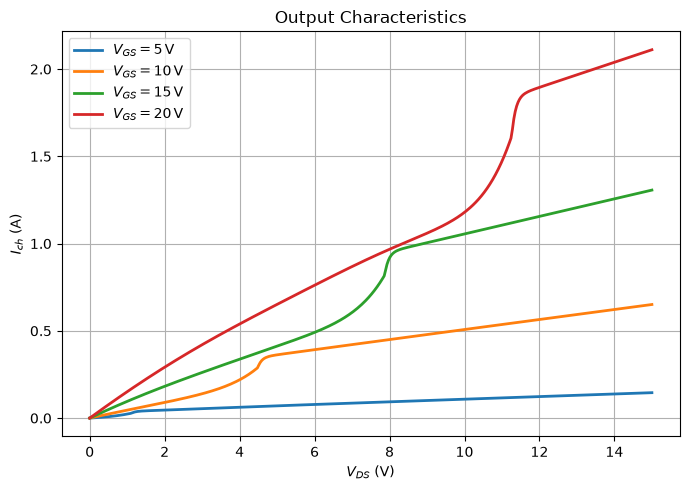

: 

In [ ]:
N_plot = 400

Vds_plot = torch.linspace(
    VDS_MIN,
    VDS_MAX,
    N_plot,
    dtype=dtype,
    device=device
).reshape(-1, 1)


VGS_PLOT = [
    5.0,
    10.0,
    15.0,
    20.0,
]

plt.figure(
    figsize=(7, 5)
)


with torch.no_grad():

    for VGS_VALUE in VGS_PLOT:

        Vgs_plot = torch.full_like(
            Vds_plot,
            VGS_VALUE
        )


        # ----------------------------------------------------
        # Source-side surface potential
        # ----------------------------------------------------

        phis_s0 = predict_phis_source(
            Model,
            Vgs_plot
        )


        # ----------------------------------------------------
        # Drain-side surface potential
        # ----------------------------------------------------

        phis_sL = predict_phis_drain(
            Model,
            Vgs_plot,
            Vds_plot
        )


        # ----------------------------------------------------
        # Channel current
        # ----------------------------------------------------

        Ich_plot = channel_current_Ich(
            Vgs_plot,
            Vds_plot,

            phis_s0,
            phis_sL,

            Vfbs0,
            Cox,
            Qox,

            Dit_mid,
            Dit_edge,
            sigma_it,

            Ec_minus_Ei,

            T,
            NA,
            Eg,
            eps_sic,

            W_eff_cm,
            Lch_cm,
            mu_eff_cm2_Vs,
            lambda_clm,
        )


        plt.plot(
            Vds_plot.cpu().numpy(),
            Ich_plot.cpu().numpy(),
            linewidth=2,
            label=rf"$V_{{GS}}={VGS_VALUE:.0f}\,\mathrm{{V}}$"
        )


plt.xlabel(
    r"$V_{DS}$ (V)"
)

plt.ylabel(
    r"$I_{ch}$ (A)"
)

plt.title(
    r"Output Characteristics"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

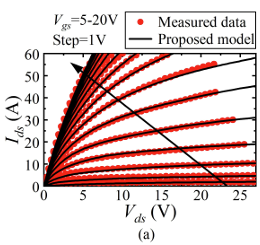